# Code to generate Figure 2 subplots

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import NullLocator
from scipy.stats import mannwhitneyu
from tqdm import trange
import matplotlib.colors as mcolors
from tqdm import tqdm, trange
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from typing import Dict, Optional

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
DATA_PATH3 = "../../16-Y2H-data/processed-data/"
ABUNDANCE  = f"{DATA_PATH1}/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

## Figure 2a
* Create boxplots of abundance for hubs and non-hubs in mass spec and Y2H datasets
* panel a will be hubs based on degree centrality, and panel b will be hubs based on betweenness centrality

In [2]:
# load the datasets with node centrality information and get nodes in both
ms_nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")
y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step16.csv")

# while the MS data already contains mean_molecules_per_cell and median_molecules_per_cell columns derived from 
# 10.1016/j.cels.2017.12.004, we need to merge this information into the y2h_nodes network
abundance_df = (
    pd.read_csv(
        ABUNDANCE,
        usecols=[
            "Systematic Name",
            "Mean molecules per cell",
            "Median molecules per cell",
        ],
    )
    .rename(
        columns={
            "Systematic Name": "node",
            "Mean molecules per cell": "mean_molecules_per_cell",
            "Median molecules per cell": "median_molecules_per_cell",
        }
    )
)
y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")

A total of 1465 nodes are shared between the MS and Y2H networks


In [3]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = ms_nodes["degree_centrality"].quantile(1 - cut)
ms_hubs = ms_nodes[ms_nodes["degree_centrality"] >= ms_threshold]
ms_nothub  = ms_nodes[ms_nodes["degree_centrality"] <  ms_threshold]

y2h_threshold = y2h_nodes["degree_centrality"].quantile(1 - cut)
y2h_hubs   = y2h_nodes[y2h_nodes["degree_centrality"] >= y2h_threshold]
y2h_nothub = y2h_nodes[y2h_nodes["degree_centrality"] <  y2h_threshold]

print (f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print (f"Threshold for defining a hub in Y2H datais {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01182; there are 393 hubs and 3534 non hubs
Threshold for defining a hub in Y2H datais 0.00297; there are 223 hubs and 1795 non hubs


Compute medians in each group (hubs and non-hubs) within each dataset along with bootstrapped 95% confidence intervals

In [4]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid huge memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_for_log(s):
    return (
        s.replace([np.inf, -np.inf], np.nan)
         .dropna()
         .loc[lambda x: x > 0]
    )

ms_nothub_vals  = clean_for_log(ms_nothub["mean_molecules_per_cell"])
ms_hub_vals     = clean_for_log(ms_hubs["mean_molecules_per_cell"])
y2h_nothub_vals = clean_for_log(y2h_nothub["mean_molecules_per_cell"])
y2h_hub_vals    = clean_for_log(y2h_hubs["mean_molecules_per_cell"])

groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:16<00:00, 62110.05it/s]


MS hubs: median=9306.00, 95% CI=(7726.00, 11208.00), n=385)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:52<00:00, 18879.02it/s]


MS non-hubs: median=3532.00, 95% CI=(3386.00, 3685.00), n=3468)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:14<00:00, 70722.36it/s]


Y2H hubs: median=3299.50, 95% CI=(2714.50, 3937.00), n=220)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:31<00:00, 31711.12it/s]

Y2H non-hubs: median=3175.00, 95% CI=(3020.00, 3389.00), n=1658)


In [5]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

### ONE-SIDED tests for greater abundance in hubs versus non-hubs

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="greater")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("\n=== (greater) Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===

MS hubs vs MS non-hubs
n(hubs) = 385, n(non-hubs) = 3468
median(hubs) = 9306.00, median(non-hubs) = 3532.00
U = 1023419.00, p = 3.544e-66

Y2H hubs vs Y2H non-hubs
n(hubs) = 220, n(non-hubs) = 1658
median(hubs) = 3299.50, median(non-hubs) = 3175.00
U = 185540.50, p = 0.6759

=== (greater) Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===

MS hubs vs MS non-hubs
n(hubs) = 385, n(non-hubs) = 3468
median(hubs) = 9306.00, median(non-hubs) = 3532.00
U = 1023419.00, p = 1.772e-66

Y2H hubs vs Y2H non-hubs
n(hubs) = 220, n(non-hubs) = 1658
median(hubs) = 3299.50, median(non-hubs) = 3175.00
U = 185540.50, p = 0.3379


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31184/3168371359.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


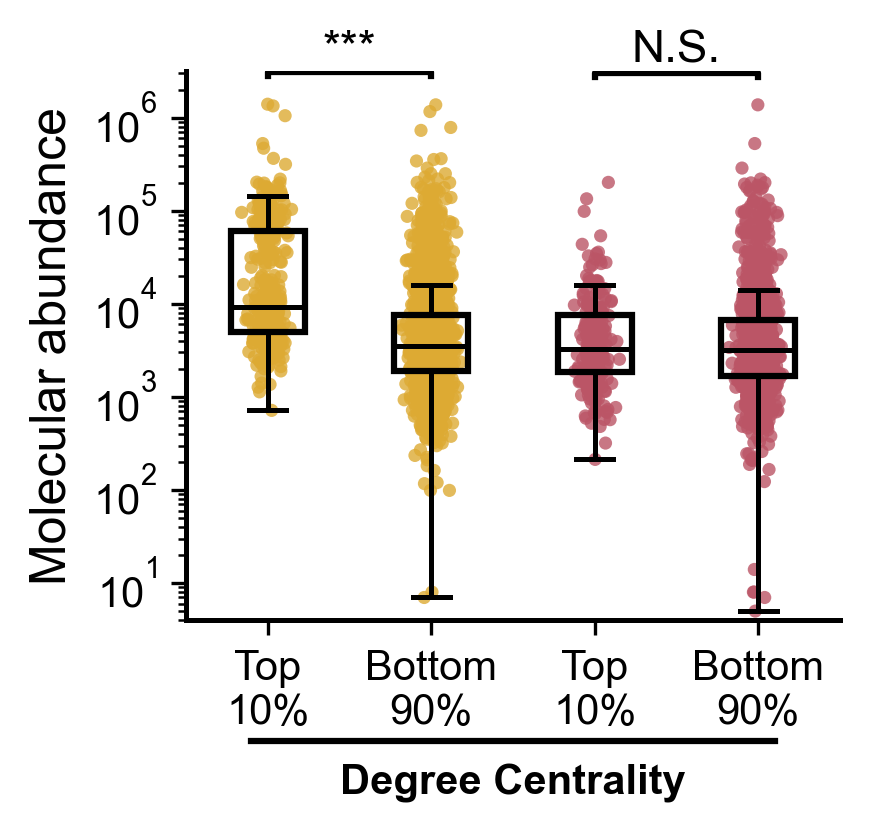

In [6]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals, y2h_hub_vals, y2h_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR,       Y2H_COLOR,    Y2H_COLOR]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )
  
# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%", "Top\n10%", "Bottom\n90%"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_yscale("log")
ax.set_ylim(4, 3200000)

ax.set_ylabel("Molecular abundance", fontsize=12)
#ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ms_pair_max  = max(ms_hub_vals.max(), ms_nothub_vals.max())
y2h_pair_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

ms_y  = ms_pair_max * 2.0
y2h_y = y2h_pair_max * 2.0


add_bracket_with_text(ax, 1, 2, ms_y,  "***")
add_bracket_with_text(ax, 3, 4, y2h_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS under boxes 1–2
ax.plot(
    [0.9, 4.1], [-0.22, -0.22],
    transform=trans,
    clip_on=False,
    color='black',
    lw=1.5,
)
ax.text(
    2.5, -0.26, "Degree Centrality",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color='black',
)

# Y2H under boxes 3–4
#ax.plot(
#    [2.9, 4.1], [-0.20, -0.20],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    3.5, -0.24, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("2a.svg")
plt.show()

## Figure 2d

Do the same thing again but for the betweenness centrality

In [7]:
# determine which nodes are bottlenecks based on percentile cutoff for betweenness centrality
cut = 0.10
ms_threshold = ms_nodes["betweenness_centrality"].quantile(1 - cut)
ms_hubs = ms_nodes[ms_nodes["betweenness_centrality"] >= ms_threshold]
ms_nothub  = ms_nodes[ms_nodes["betweenness_centrality"] <  ms_threshold]

y2h_threshold = y2h_nodes["betweenness_centrality"].quantile(1 - cut)
y2h_hubs   = y2h_nodes[y2h_nodes["betweenness_centrality"] >= y2h_threshold]
y2h_nothub = y2h_nodes[y2h_nodes["betweenness_centrality"] <  y2h_threshold]

print (f"Threshold for defining a bottleneck in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} bottlenecks and {len(ms_nothub)} non bottlenecks")
print (f"Threshold for defining a bottleneck in Y2H datais {y2h_threshold:.5f}; there are {len(y2h_hubs)} bottlenecks and {len(y2h_nothub)} non bottlenecks")

Threshold for defining a bottleneck in MS data is 0.00178; there are 393 bottlenecks and 3534 non bottlenecks
Threshold for defining a bottleneck in Y2H datais 0.00366; there are 202 bottlenecks and 1816 non bottlenecks


In [8]:
ms_nothub_vals  = clean_for_log(ms_nothub["mean_molecules_per_cell"])
ms_hub_vals     = clean_for_log(ms_hubs["mean_molecules_per_cell"])
y2h_nothub_vals = clean_for_log(y2h_nothub["mean_molecules_per_cell"])
y2h_hub_vals    = clean_for_log(y2h_hubs["mean_molecules_per_cell"])

groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:16<00:00, 61465.71it/s]


MS hubs: median=7819.00, 95% CI=(6604.00, 9390.00), n=391)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:54<00:00, 18321.57it/s]


MS non-hubs: median=3642.50, 95% CI=(3508.00, 3816.50), n=3462)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:13<00:00, 71955.93it/s]


Y2H hubs: median=3019.00, 95% CI=(2610.00, 3830.00), n=195)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:32<00:00, 30544.38it/s]

Y2H non-hubs: median=3195.00, 95% CI=(3034.00, 3430.00), n=1683)


In [9]:
# MS: bottlenecks vs non-bottlenecks
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: bottlenecks vs non-bottlenecks
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

### ONE-SIDED tests for greater abundance in bottlenecks

# MS: bottlenecks vs non-bottlenecks
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="greater")

# Y2H: bottlenecks vs non-bottlenecks
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="greater")

print("\n=== (greater) Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 391, n(non-hubs) = 3462
median(hubs) = 7819.00, median(non-hubs) = 3642.50
U = 920282.00, p = 1.681e-31

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 195, n(non-hubs) = 1683
median(hubs) = 3019.00, median(non-hubs) = 3195.00
U = 160526.50, p = 0.6189

=== (greater) Mann–Whitney U tests on mean_molecules_per_cell (raw values) ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 391, n(non-hubs) = 3462
median(hubs) = 7819.00, median(non-hubs) = 3642.50
U = 920282.00, p = 8.407e-32

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 195, n(non-hubs) = 1683
median(hubs) = 3019.00, median(non-hubs) = 3195.00
U = 160526.50, p = 0.6906


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31184/1788560004.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


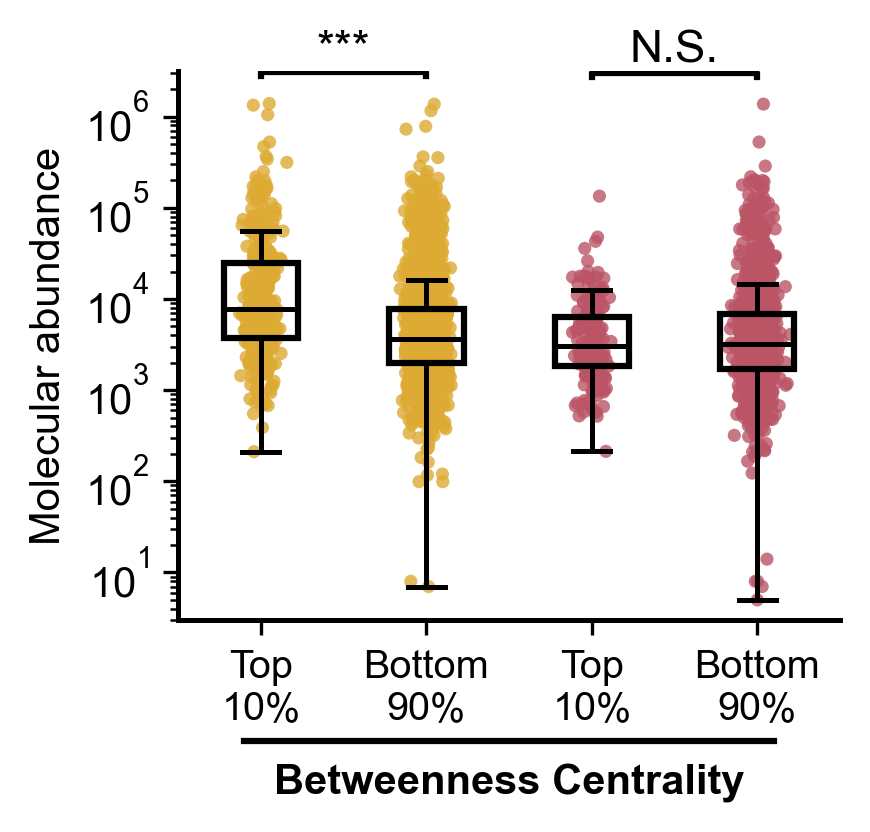

In [10]:
fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals, y2h_hub_vals, y2h_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR,       Y2H_COLOR,    Y2H_COLOR]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%", "Top\n10%", "Bottom\n90%"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_yscale("log")
#ax.set_ylim(1, 1e7)
ax.set_ylim(3, 3200000)

ax.set_ylabel("Molecular abundance")
#ax.set_title("Betweenness Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ms_pair_max  = max(ms_hub_vals.max(), ms_nothub_vals.max())
y2h_pair_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

ms_y  = ms_pair_max * 2.0
y2h_y = y2h_pair_max * 2.0

add_bracket_with_text(ax, 1, 2, ms_y,  "***")
add_bracket_with_text(ax, 3, 4, y2h_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS under boxes 1–2
ax.plot(
    [0.9, 4.1], [-0.22, -0.22],
    transform=trans,
    clip_on=False,
    color='black',
    lw=1.5,
)
ax.text(
    2.5, -0.26, "Betweenness Centrality",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color='black',
)

# Y2H under boxes 3–4
#ax.plot(
#    [2.9, 4.1], [-0.29, -0.29],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    3.5, -0.31, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)

ax.tick_params(axis="x", labelsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(0)   # or 45
    label.set_ha("center")
    label.set_fontsize(9.5)

plt.tight_layout()
plt.savefig("2d.svg")
plt.show()

## Figure 2b

* Create boxplots of protein half-life (min) for hubs and non-hubs in mass spec and Y2H datasets 

In [11]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = ms_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = ms_nodes[ms_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = ms_nodes[ms_nodes['degree_centrality'] <  ms_threshold]

y2h_threshold = ms_nodes['Y2H_degree_centrality'].quantile(1 - cut)
y2h_hubs      = ms_nodes[ms_nodes['Y2H_degree_centrality'] >= y2h_threshold]
y2h_nothub    = ms_nodes[ms_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01182; there are 393 hubs and 3534 non hubs
Threshold for defining a hub in Y2H data is 0.00297; there are 168 hubs and 1297 non hubs


In [12]:
ms_nothub_vals  = clean_for_log(ms_nothub["Villen_halflife_min"])
ms_hub_vals     = clean_for_log(ms_hubs["Villen_halflife_min"])
y2h_nothub_vals = clean_for_log(y2h_nothub["Villen_halflife_min"])
y2h_hub_vals    = clean_for_log(y2h_hubs["Villen_halflife_min"])

groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:16<00:00, 62058.97it/s]


MS hubs: median=91.50, 95% CI=(90.60, 92.70), n=340)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:40<00:00, 24606.61it/s]


MS non-hubs: median=134.10, 95% CI=(131.40, 136.80), n=2370)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 78769.63it/s]


Y2H hubs: median=144.00, 95% CI=(135.00, 153.00), n=120)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:22<00:00, 43762.44it/s]

Y2H non-hubs: median=132.60, 95% CI=(129.00, 136.20), n=927)


In [13]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

### ONE-SIDED, hubs have lower halflife than non-hubs

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="less")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="less")

print("\n=== (less) Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H hubs vs Y2H non-hubs")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS hubs vs MS non-hubs
n(hubs) = 340, n(non-hubs) = 2370
median(hubs) = 91.50, median(non-hubs) = 134.10
U = 230247.50, p = 1.717e-37

Y2H hubs vs Y2H non-hubs
n(hubs) = 120, n(non-hubs) = 927
median(hubs) = 144.00, median(non-hubs) = 132.60
U = 64396.00, p = 0.00487

=== (less) Mann–Whitney U tests on Villen_halflife_min ===

MS hubs vs MS non-hubs
n(hubs) = 340, n(non-hubs) = 2370
median(hubs) = 91.50, median(non-hubs) = 134.10
U = 230247.50, p = 8.586e-38

Y2H hubs vs Y2H non-hubs
n(hubs) = 120, n(non-hubs) = 927
median(hubs) = 144.00, median(non-hubs) = 132.60
U = 64396.00, p = 0.9976


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31184/350796363.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


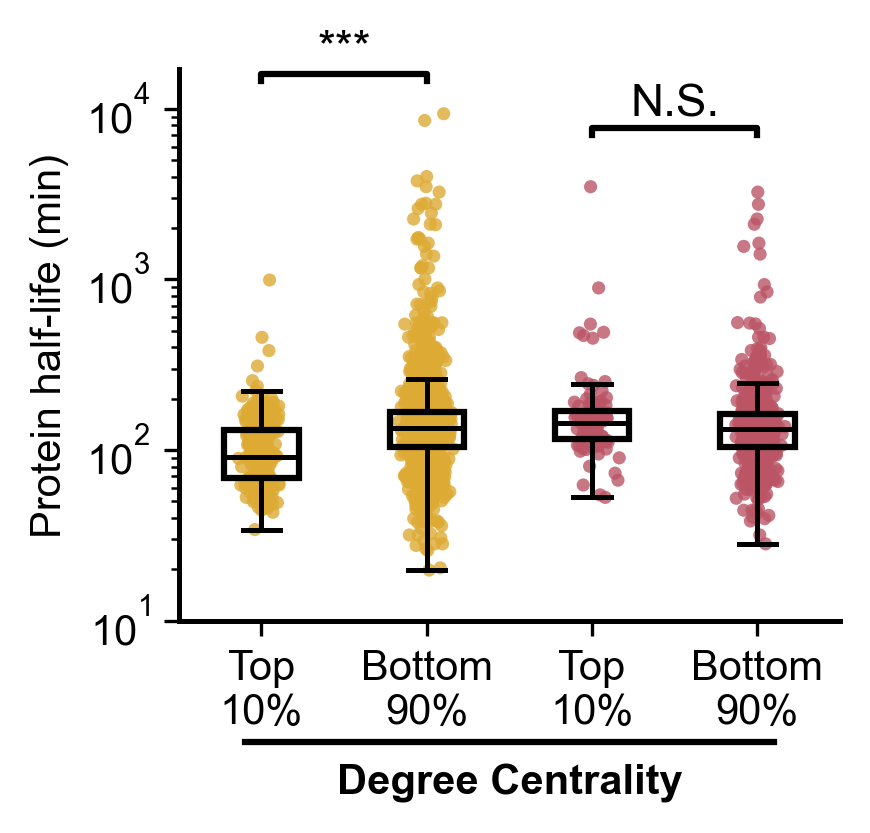

In [14]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals, y2h_hub_vals, y2h_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR,       Y2H_COLOR,    Y2H_COLOR]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%", "Top\n10%", "Bottom\n90%"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_yscale("log")
ax.set_ylim(18, 17000)

ax.set_ylabel("Protein half-life (min)")
#ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ms_pair_max  = max(ms_hub_vals.max(), ms_nothub_vals.max())
y2h_pair_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

ms_y  = 14500
y2h_y = y2h_pair_max * 2.0

add_bracket_with_text(ax, 1, 2, ms_y,  "***")
add_bracket_with_text(ax, 3, 4, y2h_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS under boxes 1–2
ax.plot(
    [0.9, 4.1], [-0.22, -0.22],
    transform=trans,
    clip_on=False,
    color='black',
    lw=1.5,
)
ax.text(
    2.5, -0.26, "Degree Centrality",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color='black',
)

# Y2H under boxes 3–4
#ax.plot(
#    [2.9, 4.1], [-0.29, -0.29],
#    transform=trans,
#    clip_on=False,
#    color=Y2H_COLOR,
#    lw=1.5,
#)
#ax.text(
#    3.5, -0.31, "Y2H",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=Y2H_COLOR,
#)
plt.xticks(fontsize=10)
plt.yticks([10, 100, 1000, 10000])
plt.tight_layout()
plt.savefig("2b.svg")
plt.show()

## Figure 2e

* Create boxplots of protein half-life (min) for bottlenecks and non-bottlenecks in mass spec and Y2H datasets 

In [15]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10
ms_threshold = ms_nodes['betweenness_centrality'].quantile(1 - cut)
ms_hubs     = ms_nodes[ms_nodes['betweenness_centrality'] >= ms_threshold]
ms_nothub   = ms_nodes[ms_nodes['betweenness_centrality'] <  ms_threshold]

y2h_threshold = ms_nodes['Y2H_betweenness_centrality'].quantile(1 - cut)
y2h_hubs      = ms_nodes[ms_nodes['Y2H_betweenness_centrality'] >= y2h_threshold]
y2h_nothub    = ms_nodes[ms_nodes['Y2H_betweenness_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.00178; there are 393 hubs and 3534 non hubs
Threshold for defining a hub in Y2H data is 0.00388; there are 147 hubs and 1318 non hubs


In [16]:
ms_nothub_vals  = clean_for_log(ms_nothub["Villen_halflife_min"])
ms_hub_vals     = clean_for_log(ms_hubs["Villen_halflife_min"])
y2h_nothub_vals = clean_for_log(y2h_nothub["Villen_halflife_min"])
y2h_hub_vals    = clean_for_log(y2h_hubs["Villen_halflife_min"])

groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:15<00:00, 63558.76it/s]


MS hubs: median=126.90, 95% CI=(119.40, 135.60), n=328)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:40<00:00, 24403.12it/s]


MS non-hubs: median=130.20, 95% CI=(127.20, 132.60), n=2382)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:12<00:00, 79837.36it/s]


Y2H hubs: median=141.60, 95% CI=(134.40, 151.20), n=101)


Bootstrapping medians: 100%|████████████| 1000000/1000000 [00:23<00:00, 43167.48it/s]

Y2H non-hubs: median=132.90, 95% CI=(129.60, 136.80), n=946)


In [17]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="less")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="less")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 328, n(non-hubs) = 2382
median(hubs) = 126.90, median(non-hubs) = 130.20
U = 369639.50, p = 0.1138

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 101, n(non-hubs) = 946
median(hubs) = 141.60, median(non-hubs) = 132.90
U = 54499.00, p = 0.0199
=== Mann–Whitney U tests on Villen_halflife_min ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 328, n(non-hubs) = 2382
median(hubs) = 126.90, median(non-hubs) = 130.20
U = 369639.50, p = 0.05691

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 101, n(non-hubs) = 946
median(hubs) = 141.60, median(non-hubs) = 132.90
U = 54499.00, p = 0.9901


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_31184/1364986180.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


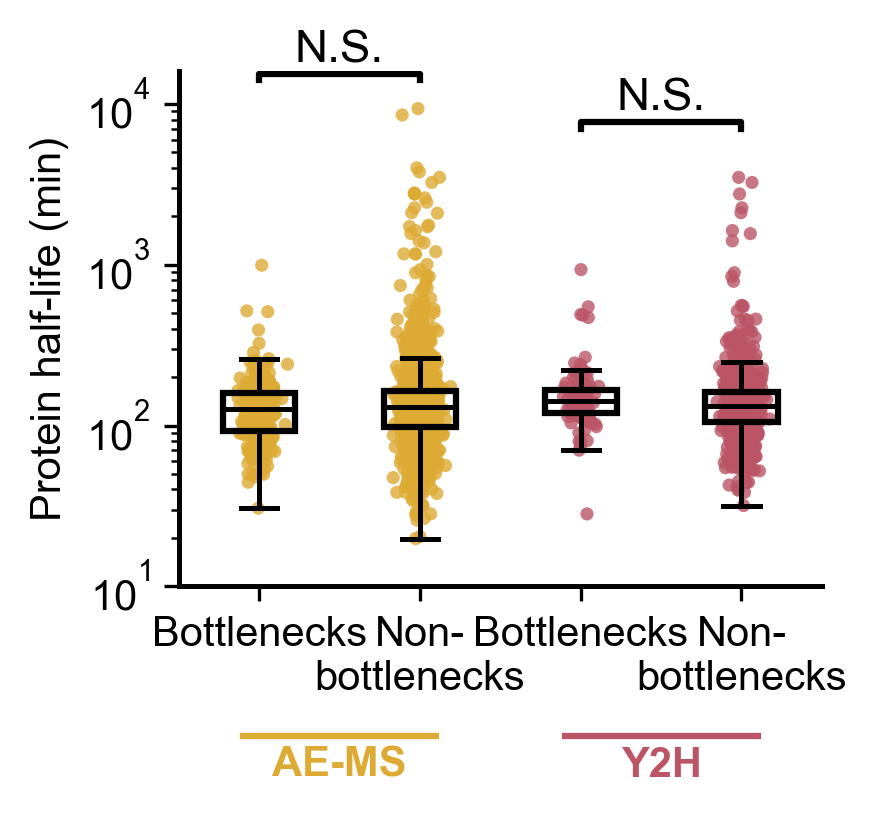

In [18]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals, y2h_hub_vals, y2h_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR,       Y2H_COLOR,    Y2H_COLOR]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Bottlenecks", "Non-\nbottlenecks", "Bottlenecks", "Non-\nbottlenecks"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_yscale("log")
ax.set_ylim(12, 16000)

ax.set_ylabel("Protein half-life (min)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ms_pair_max  = max(ms_hub_vals.max(), ms_nothub_vals.max())
y2h_pair_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

#ms_y  = ms_pair_max * 2.0
ms_y  = 14000
y2h_y = y2h_pair_max * 2.0

add_bracket_with_text(ax, 1, 2, ms_y,  "N.S.")
add_bracket_with_text(ax, 3, 4, y2h_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS under boxes 1–2
ax.plot(
    [0.9, 2.1], [-0.29, -0.29],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.5, -0.31, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

# Y2H under boxes 3–4
ax.plot(
    [2.9, 4.1], [-0.29, -0.29],
    transform=trans,
    clip_on=False,
    color=Y2H_COLOR,
    lw=1.5,
)
ax.text(
    3.5, -0.31, "Y2H",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=Y2H_COLOR,
)
ax.tick_params(axis="x", labelsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(0)   # or 45
    label.set_ha("center")
    label.set_fontsize(10)
plt.yticks([10, 100, 1000, 10000])
plt.tight_layout()
plt.savefig("2e.svg")
plt.show()

## Figure 2c

In [19]:
def bootstrap_ct_fast(
    df: pd.DataFrame,
    col1: str,
    col2: str,
    n: Optional[int] = None,
    B: int = 1_000_000,
    alpha: float = 0.05,
    seed: Optional[int] = 0,
    correction: float = 0.0,   
) -> Dict[str, object]:
    
    sub = df[[col1, col2]].dropna().astype(bool)
    N = len(sub)
    if N == 0:
        raise ValueError("No rows after dropping NA.")
    if n is None:
        n = N

    # observed counts
    a = int(((sub[col1]) & (sub[col2])).sum())              # True, True
    b = int(((sub[col1]) & (~sub[col2])).sum())             # True, False
    c = int(((~sub[col1]) & (sub[col2])).sum())             # False, True
    d = int(((~sub[col1]) & (~sub[col2])).sum())            # False, False

    table = np.array([[a, b],
                      [c, d]], dtype=int)

    # "Observed" odds ratio from Fisher's exact test (fine to do once)
    odds_ratio_fisher, p_value = fisher_exact(table, alternative="two-sided")

    # Also compute the standard cross-product OR (used for bootstrap below)
    or_obs = ((a + correction) * (d + correction)) / ((b + correction) * (c + correction))
    odds1_obs = (a + correction) / (b + correction)
    odds2_obs = (c + correction) / (d + correction)

    # Multinomial probabilities from empirical distribution
    p = np.array([a, b, c, d], dtype=float) / N

    rng = np.random.default_rng(seed)

    # Draw all bootstrap tables at once (very fast)
    boot = rng.multinomial(n, p, size=B).astype(np.int32)
    boot_a, boot_b, boot_c, boot_d = boot.T  # each is (B,)

    # Vectorized odds / OR with correction
    boot_odds1 = (boot_a + correction) / (boot_b + correction)
    boot_odds2 = (boot_c + correction) / (boot_d + correction)
    boot_or    = ((boot_a + correction) * (boot_d + correction)) / ((boot_b + correction) * (boot_c + correction))

    # percentile CIs
    lo_q = alpha / 2
    hi_q = 1 - alpha / 2

    def ci(x: np.ndarray):
        return (float(np.quantile(x, lo_q)), float(np.quantile(x, hi_q)))

    a_ci = ci(boot_a); b_ci = ci(boot_b); c_ci = ci(boot_c); d_ci = ci(boot_d)
    odds1_ci = ci(boot_odds1); odds2_ci = ci(boot_odds2); or_ci = ci(boot_or)

    return {
        "a": a, "b": b, "c": c, "d": d,
        "a_lower": a_ci[0], "a_upper": a_ci[1],
        "b_lower": b_ci[0], "b_upper": b_ci[1],
        "c_lower": c_ci[0], "c_upper": c_ci[1],
        "d_lower": d_ci[0], "d_upper": d_ci[1],

        # Fisher OR / p-value for the observed table 
        "odds_ratio_fisher": float(odds_ratio_fisher),
        "p_value_fisher": float(p_value),

        # bootstrap distribution information for the cross-product OR and per-row odds
        "odds_ratio": float(or_obs), "odds_ratio_lower": or_ci[0], "odds_ratio_upper": or_ci[1],
        "row1_odds": float(odds1_obs), "row1_odds_lower": odds1_ci[0], "row1_odds_upper": odds1_ci[1],
        "row2_odds": float(odds2_obs), "row2_odds_lower": odds2_ci[0], "row2_odds_upper": odds2_ci[1],

    }

In [20]:
# convert your hub tables into boolean columns
ms_nodes = ms_nodes.copy()

ms_nodes["ms_hubs"]  = ms_nodes["node"].isin(ms_hubs["node"])
ms_nodes["y2h_hubs"] = ms_nodes["node"].isin(y2h_hubs["node"])

groups = [
    ("MS hubs",  "ms_hubs",  MS_COLOR),
    ("Y2H hubs", "y2h_hubs", Y2H_COLOR),
]

# Bootstrap + Fisher for both networks
results_ms = bootstrap_ct_fast(
    ms_nodes,
    col1="ms_hubs",
    col2="essential",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)

print("\n" + "="*70)
print("MS NETWORK")
print("="*70)

print("Contingency table:")
print("                Essential     Non-essential")
print("Hub             {:>9d}          {:>9d}     ← a = hub & essential".format(
    results_ms['a'], results_ms['b']))
print("Non-hub         {:>9d}          {:>9d}     ← c = non-hub & essential".format(
    results_ms['c'], results_ms['d']))
print()

print("Fisher's exact test:")
print(f"  Odds ratio (hub vs non-hub) = {results_ms['odds_ratio_fisher']:.3f}")
print(f"  p-value                     = {results_ms['p_value_fisher']:.4g}")
print()

print("Bootstrap conditional odds (with Haldane–Anscombe correction):")
print(f"  Odds(essential | MS hub)     = {results_ms['row1_odds']:.3f}")
print(f"    95% CI                     = {results_ms['row1_odds_lower']:.3f} – {results_ms['row1_odds_upper']:.3f}")
print(f"  Odds(essential | MS non-hub) = {results_ms['row2_odds']:.3f}")
print(f"    95% CI                     = {results_ms['row2_odds_lower']:.3f} – {results_ms['row2_odds_upper']:.3f}")
print()

if results_ms['row1_odds'] > results_ms['row2_odds']:
    print("→ Essential proteins are enriched among MS hubs compared to non-hubs")
else:
    print("→ Essential proteins are NOT enriched among MS hubs (or depleted)")
print("-"*70)

results_y2h = bootstrap_ct_fast(
    ms_nodes,
    col1="y2h_hubs",
    col2="essential",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)


print("\n" + "="*70)
print("Y2H NETWORK")
print("="*70)

print("Contingency table:")
print("                Essential     Non-essential")
print("Hub             {:>9d}          {:>9d}     ← a = hub & essential".format(
    results_y2h['a'], results_y2h['b']))
print("Non-hub         {:>9d}          {:>9d}     ← c = non-hub & essential".format(
    results_y2h['c'], results_y2h['d']))
print()

print("Fisher's exact test:")
print(f"  Odds ratio (hub vs non-hub) = {results_y2h['odds_ratio_fisher']:.3f}")
print(f"  p-value                     = {results_y2h['p_value_fisher']:.4g}")
print()

print("Bootstrap conditional odds (with Haldane–Anscombe correction):")
print(f"  Odds(essential | Y2H hub)     = {results_y2h['row1_odds']:.3f}")
print(f"    95% CI                      = {results_y2h['row1_odds_lower']:.3f} – {results_y2h['row1_odds_upper']:.3f}")
print(f"  Odds(essential | Y2H non-hub) = {results_y2h['row2_odds']:.3f}")
print(f"    95% CI                      = {results_y2h['row2_odds_lower']:.3f} – {results_y2h['row2_odds_upper']:.3f}")
print()

if results_y2h['row1_odds'] > results_y2h['row2_odds']:
    print("→ Essential proteins are enriched among Y2H hubs compared to non-hubs")
else:
    print("→ Essential proteins are NOT enriched among Y2H hubs (or depleted)")
print("-"*70)



# Extract the four conditional odds + CIs
# MS
odds_ms_hub_ess     = results_ms["row1_odds"]          # essential | MS hub
odds_ms_nonhub_ess  = results_ms["row2_odds"]          # essential | not MS hub
ci_ms_hub_ess       = [results_ms["row1_odds_lower"], results_ms["row1_odds_upper"]]
ci_ms_nonhub_ess    = [results_ms["row2_odds_lower"], results_ms["row2_odds_upper"]]

# Y2H
odds_y2h_hub_ess    = results_y2h["row1_odds"]         # essential | Y2H hub
odds_y2h_nonhub_ess = results_y2h["row2_odds"]         # essential | not Y2H hub
ci_y2h_hub_ess      = [results_y2h["row1_odds_lower"], results_y2h["row1_odds_upper"]]
ci_y2h_nonhub_ess   = [results_y2h["row2_odds_lower"], results_y2h["row2_odds_upper"]]

# Print results 
def print_odds_result(name, odds_hub, ci_hub, odds_nonhub, ci_nonhub):
    print(f"\n{name}:")
    print(f"  Odds essential | hub      = {odds_hub:.2f}  (95% CI: {ci_hub[0]:.2f} – {ci_hub[1]:.2f})")
    print(f"  Odds essential | non-hub  = {odds_nonhub:.2f}  (95% CI: {ci_nonhub[0]:.2f} – {ci_nonhub[1]:.2f})")
    diff = odds_hub - odds_nonhub
    direction = "higher" if diff > 0 else "lower"
    print(f"  → Essential proteins are {direction} in hubs than in non-hubs")

print_odds_result("MS", odds_ms_hub_ess, ci_ms_hub_ess, odds_ms_nonhub_ess, ci_ms_nonhub_ess)
print_odds_result("Y2H", odds_y2h_hub_ess, ci_y2h_hub_ess, odds_y2h_nonhub_ess, ci_y2h_nonhub_ess)


MS NETWORK
Contingency table:
                Essential     Non-essential
Hub                   148                245     ← a = hub & essential
Non-hub               874               2660     ← c = non-hub & essential

Fisher's exact test:
  Odds ratio (hub vs non-hub) = 1.839
  p-value                     = 8.325e-08

Bootstrap conditional odds (with Haldane–Anscombe correction):
  Odds(essential | MS hub)     = 0.605
    95% CI                     = 0.491 – 0.739
  Odds(essential | MS non-hub) = 0.329
    95% CI                     = 0.304 – 0.354

→ Essential proteins are enriched among MS hubs compared to non-hubs
----------------------------------------------------------------------

Y2H NETWORK
Contingency table:
                Essential     Non-essential
Hub                    55                 92     ← a = hub & essential
Non-hub               967               2813     ← c = non-hub & essential

Fisher's exact test:
  Odds ratio (hub vs non-hub) = 1.739
  p-value         

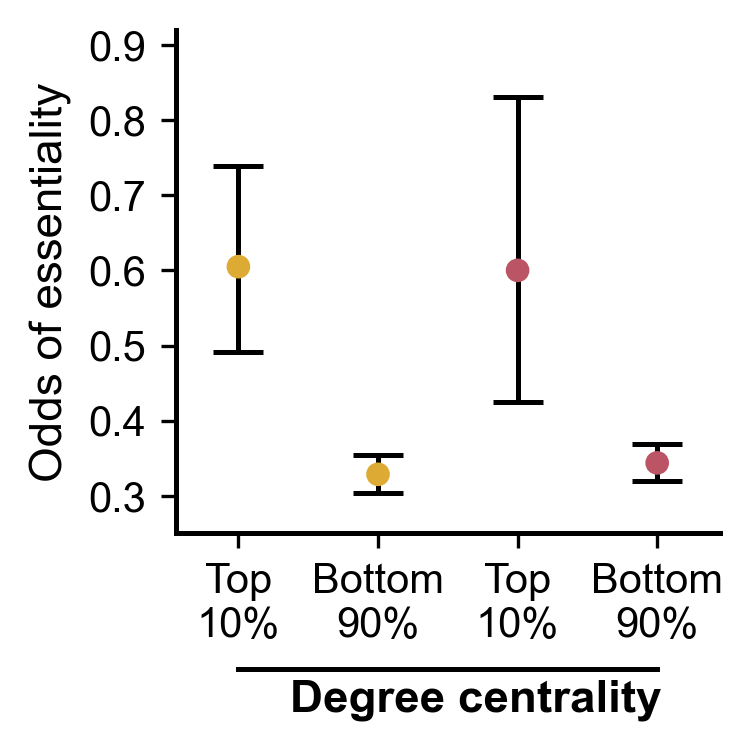

In [21]:
# Prepare data for plotting ODDS RATIOS
odds_values = np.array([
    odds_ms_hub_ess,
    odds_ms_nonhub_ess,
    odds_y2h_hub_ess,
    odds_y2h_nonhub_ess
])

ci_lower = np.array([
    ci_ms_hub_ess[0],
    ci_ms_nonhub_ess[0],
    ci_y2h_hub_ess[0],
    ci_y2h_nonhub_ess[0]
])

ci_upper = np.array([
    ci_ms_hub_ess[1],
    ci_ms_nonhub_ess[1],
    ci_y2h_hub_ess[1],
    ci_y2h_nonhub_ess[1]
])

yerr = np.vstack([odds_values - ci_lower, ci_upper - odds_values])

labels = [
    "Top\n10%",
    "Bottom\n90%",
    "Top\n10%",
    "Bottom\n90%"
]

colors = [MS_COLOR, MS_COLOR, Y2H_COLOR, Y2H_COLOR]
x_pos = np.array([1.8, 2.8, 3.8, 4.8])   # gap between MS and Y2H groups

fig, ax = plt.subplots(figsize=(2.6, 2.6))

# Points on top (colored)
ax.scatter(
    x=x_pos,
    y=odds_values,
    s=20,
    color=colors,
    #edgecolor="black",
    linewidth=1.2,
    zorder=3
)
# Add error bars
ax.errorbar(
    x=x_pos,
    y=odds_values,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    linewidth=1.2,
    capsize=6,
    capthick=1.2,
    zorder=2
)

# ── Degree centrality line and label 
trans = ax.get_xaxis_transform()

# Labelling degree centrality
ax.plot(
    [1.8, 4.8], [-0.27, -0.27],
    transform=trans,
    clip_on=False,
    color='black',
    lw=1.2,
)
ax.text(
    3.5, -0.29, "Degree centrality",
    transform=trans,
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color='black',
)

# Axes and style
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11, ha='center')
ax.margins(x=0.15)
ax.set_ylabel("Odds of essentiality", fontsize=11)
ax.set_ylim(0.25, 0.92)
ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=10)
plt.subplots_adjust(bottom=0.24)

plt.tight_layout()

plt.savefig("2c.svg", bbox_inches="tight", dpi=400)
plt.show()

## Figure 2f

In [22]:
# convert your hub tables into boolean columns
ms_nodes = ms_nodes.copy()

ms_nodes["ms_hubs"]  = ms_nodes["node"].isin(ms_hubs["node"])
ms_nodes["y2h_hubs"] = ms_nodes["node"].isin(y2h_hubs["node"])

groups = [
    ("MS hubs",  "ms_hubs",  MS_COLOR),
    ("Y2H hubs", "y2h_hubs", Y2H_COLOR),
]

# Bootstrap + Fisher for both networks
results_ms = bootstrap_ct_fast(
    ms_nodes,
    col1="ms_hubs",
    col2="essential",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)

print("\n" + "="*70)
print("MS NETWORK")
print("="*70)

print("Contingency table:")
print("                Essential     Non-essential")
print("Hub             {:>9d}          {:>9d}     ← a = hub & essential".format(
    results_ms['a'], results_ms['b']))
print("Non-hub         {:>9d}          {:>9d}     ← c = non-hub & essential".format(
    results_ms['c'], results_ms['d']))
print()

print("Fisher's exact test:")
print(f"  Odds ratio (hub vs non-hub) = {results_ms['odds_ratio_fisher']:.3f}")
print(f"  p-value                     = {results_ms['p_value_fisher']:.4g}")
print()

print("Bootstrap conditional odds (with Haldane–Anscombe correction):")
print(f"  Odds(essential | MS hub)     = {results_ms['row1_odds']:.3f}")
print(f"    95% CI                     = {results_ms['row1_odds_lower']:.3f} – {results_ms['row1_odds_upper']:.3f}")
print(f"  Odds(essential | MS non-hub) = {results_ms['row2_odds']:.3f}")
print(f"    95% CI                     = {results_ms['row2_odds_lower']:.3f} – {results_ms['row2_odds_upper']:.3f}")
print()

if results_ms['row1_odds'] > results_ms['row2_odds']:
    print("→ Essential proteins are enriched among MS hubs compared to non-hubs")
else:
    print("→ Essential proteins are NOT enriched among MS hubs (or depleted)")
print("-"*70)

results_y2h = bootstrap_ct_fast(
    ms_nodes,
    col1="y2h_hubs",
    col2="essential",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)


print("\n" + "="*70)
print("Y2H NETWORK")
print("="*70)

print("Contingency table:")
print("                Essential     Non-essential")
print("Hub             {:>9d}          {:>9d}     ← a = hub & essential".format(
    results_y2h['a'], results_y2h['b']))
print("Non-hub         {:>9d}          {:>9d}     ← c = non-hub & essential".format(
    results_y2h['c'], results_y2h['d']))
print()

print("Fisher's exact test:")
print(f"  Odds ratio (hub vs non-hub) = {results_y2h['odds_ratio_fisher']:.3f}")
print(f"  p-value                     = {results_y2h['p_value_fisher']:.4g}")
print()

print("Bootstrap conditional odds (with Haldane–Anscombe correction):")
print(f"  Odds(essential | Y2H hub)     = {results_y2h['row1_odds']:.3f}")
print(f"    95% CI                      = {results_y2h['row1_odds_lower']:.3f} – {results_y2h['row1_odds_upper']:.3f}")
print(f"  Odds(essential | Y2H non-hub) = {results_y2h['row2_odds']:.3f}")
print(f"    95% CI                      = {results_y2h['row2_odds_lower']:.3f} – {results_y2h['row2_odds_upper']:.3f}")
print()

if results_y2h['row1_odds'] > results_y2h['row2_odds']:
    print("→ Essential proteins are enriched among Y2H hubs compared to non-hubs")
else:
    print("→ Essential proteins are NOT enriched among Y2H hubs (or depleted)")
print("-"*70)



# Extract the four conditional odds + CIs
# MS
odds_ms_hub_ess     = results_ms["row1_odds"]          # essential | MS hub
odds_ms_nonhub_ess  = results_ms["row2_odds"]          # essential | not MS hub
ci_ms_hub_ess       = [results_ms["row1_odds_lower"], results_ms["row1_odds_upper"]]
ci_ms_nonhub_ess    = [results_ms["row2_odds_lower"], results_ms["row2_odds_upper"]]

# Y2H
odds_y2h_hub_ess    = results_y2h["row1_odds"]         # essential | Y2H hub
odds_y2h_nonhub_ess = results_y2h["row2_odds"]         # essential | not Y2H hub
ci_y2h_hub_ess      = [results_y2h["row1_odds_lower"], results_y2h["row1_odds_upper"]]
ci_y2h_nonhub_ess   = [results_y2h["row2_odds_lower"], results_y2h["row2_odds_upper"]]

# Print results 
def print_odds_result(name, odds_hub, ci_hub, odds_nonhub, ci_nonhub):
    print(f"\n{name}:")
    print(f"  Odds essential | hub      = {odds_hub:.2f}  (95% CI: {ci_hub[0]:.2f} – {ci_hub[1]:.2f})")
    print(f"  Odds essential | non-hub  = {odds_nonhub:.2f}  (95% CI: {ci_nonhub[0]:.2f} – {ci_nonhub[1]:.2f})")
    diff = odds_hub - odds_nonhub
    direction = "higher" if diff > 0 else "lower"
    print(f"  → Essential proteins are {direction} in hubs than in non-hubs")

print_odds_result("MS", odds_ms_hub_ess, ci_ms_hub_ess, odds_ms_nonhub_ess, ci_ms_nonhub_ess)
print_odds_result("Y2H", odds_y2h_hub_ess, ci_y2h_hub_ess, odds_y2h_nonhub_ess, ci_y2h_nonhub_ess)


MS NETWORK
Contingency table:
                Essential     Non-essential
Hub                   148                245     ← a = hub & essential
Non-hub               874               2660     ← c = non-hub & essential

Fisher's exact test:
  Odds ratio (hub vs non-hub) = 1.839
  p-value                     = 8.325e-08

Bootstrap conditional odds (with Haldane–Anscombe correction):
  Odds(essential | MS hub)     = 0.605
    95% CI                     = 0.491 – 0.739
  Odds(essential | MS non-hub) = 0.329
    95% CI                     = 0.304 – 0.354

→ Essential proteins are enriched among MS hubs compared to non-hubs
----------------------------------------------------------------------

Y2H NETWORK
Contingency table:
                Essential     Non-essential
Hub                    55                 92     ← a = hub & essential
Non-hub               967               2813     ← c = non-hub & essential

Fisher's exact test:
  Odds ratio (hub vs non-hub) = 1.739
  p-value         

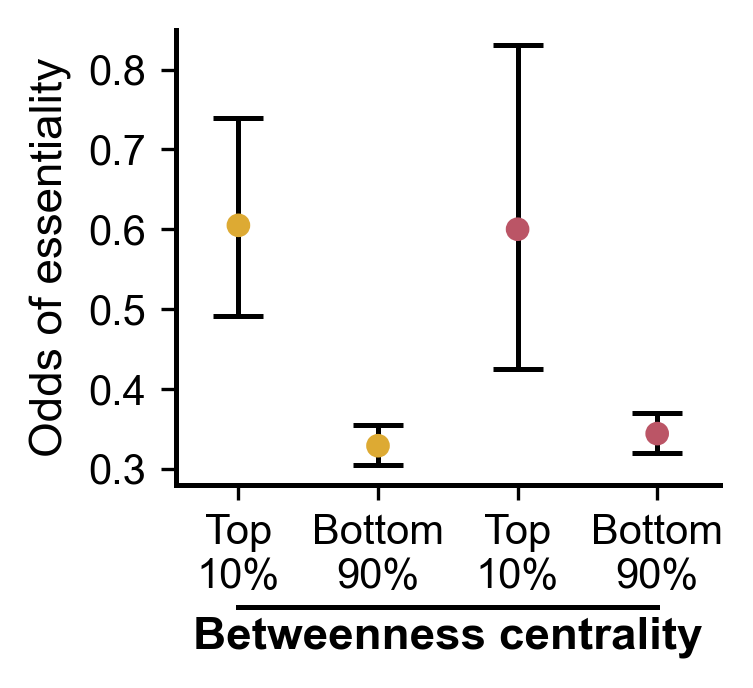

In [23]:
# Prepare data for plotting ODDS RATIOS
odds_values = np.array([
    odds_ms_hub_ess,
    odds_ms_nonhub_ess,
    odds_y2h_hub_ess,
    odds_y2h_nonhub_ess
])

ci_lower = np.array([
    ci_ms_hub_ess[0],
    ci_ms_nonhub_ess[0],
    ci_y2h_hub_ess[0],
    ci_y2h_nonhub_ess[0]
])

ci_upper = np.array([
    ci_ms_hub_ess[1],
    ci_ms_nonhub_ess[1],
    ci_y2h_hub_ess[1],
    ci_y2h_nonhub_ess[1]
])

yerr = np.vstack([odds_values - ci_lower, ci_upper - odds_values])

labels = [
    "Top\n10%",
    "Bottom\n90%",
    "Top\n10%",
    "Bottom\n90%"
]

colors = [MS_COLOR, MS_COLOR, Y2H_COLOR, Y2H_COLOR]
x_pos = np.array([1.8, 2.8, 3.8, 4.8])   # gap between MS and Y2H groups

fig, ax = plt.subplots(figsize=(2.6, 2.4))

# Points on top (colored)
ax.scatter(
    x=x_pos,
    y=odds_values,
    s=20,
    color=colors,
    #edgecolor="black",
    linewidth=1.2,
    zorder=3
)
# Add error bars
ax.errorbar(
    x=x_pos,
    y=odds_values,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    linewidth=1.2,
    capsize=6,
    capthick=1.2,
    zorder=2
)

# ── Betweenness centrality line and label 
trans = ax.get_xaxis_transform()

# Labelling betweenness centrality
ax.plot(
    [1.8, 4.8], [-0.27, -0.27],
    transform=trans,
    clip_on=False,
    color='black',
    lw=1.2,
)
ax.text(
    3.3, -0.29, "Betweenness centrality",
    transform=trans,
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color='black',
)

# Axes and style
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11, ha='center')
ax.margins(x=0.15)
ax.set_ylabel("Odds of essentiality", fontsize=11)
ax.set_ylim(0.28, 0.85)
ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=10)
plt.subplots_adjust(bottom=0.24)

plt.tight_layout()

plt.savefig("2f.svg", bbox_inches="tight", dpi=400)
plt.show()